In [42]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [43]:
file = pd.read_csv("rost_ves.csv")

file

,Рост (см),Вес (кг)
0,150,45
1,152,47
2,155,50
3,157,52
4,160,54
5,162,56
6,165,58
7,167,60
8,170,63
9,172,65


In [44]:
height = file["Рост (см)"].tolist()
weight = file["Вес (кг)"].tolist()

height, weight

([150,
  152,
  155,
  157,
  160,
  162,
  165,
  167,
  170,
  172,
  175,
  177,
  180,
  182,
  185,
  187,
  190,
  192,
  195,
  197],
 [45,
  47,
  50,
  52,
  54,
  56,
  58,
  60,
  63,
  65,
  68,
  70,
  73,
  75,
  78,
  80,
  83,
  85,
  88,
  90])

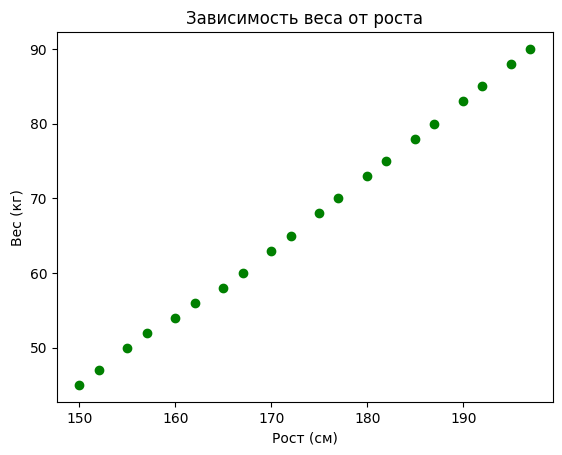

In [45]:
plot = plt.scatter(height, weight, c="green")
plt.xlabel("Рост (см)")
plt.ylabel("Вес (кг)")
plt.title("Зависимость веса от роста")
plt.show()

In [46]:
X = file[["Рост (см)"]]
y = file["Вес (кг)"]

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [48]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [60]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)

MAE: 0.46867098514220373
MSE: 0.2922262267342043
R2: 0.999132055016197


In [73]:
new_h = pd.DataFrame([185], columns=["Рост (см)"])
pred_w = model.predict(new_h)

print(f"{pred_w[0]:.2f}")

77.96
